# Travel Data Science & MLOps Capstone

## 03 — Flight Price Regression

### Objective

The objective of this notebook is to develop a machine learning model
that predicts flight prices based on flight characteristics and
temporal information.

The target variable is:

- `price`

Potential predictor variables include:

- Origin
- Destination
- Flight type
- Flight duration
- Flight distance
- Agency
- Year
- Month
- Day
- Day of week
- Weekend indicator

Multiple regression algorithms will be trained and evaluated.

The models will be compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model will be selected and saved for future
deployment.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn. metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


import joblib

print("Libraries imported successfully")

XGBoost version: 3.4.1
Libraries imported successfully


In [ ]:
  flight_data_path = "/content/processed/flight_ml_data.csv"

flight_data = pd.read_csv(
    flight_data_path
)

print("Dataset loaded successfully.")
print("Shape:", flight_data.shape)

Dataset loaded successfully.
Shape: (271888, 13)


In [ ]:
print(flight_data.duplicated().sum())

0


In [ ]:
display(flight_data.head())

,travelCode,from,to,flightType,time,distance,agency,year,month,day,day_of_week,is_weekend,price
0,0,Recife (PE),Florianopolis (SC),firstClass,1.76,676.53,FlyingDrops,2019,9,26,3,0,1434.38
1,0,Florianopolis (SC),Recife (PE),firstClass,1.76,676.53,FlyingDrops,2019,9,30,0,0,1292.29
2,1,Brasilia (DF),Florianopolis (SC),firstClass,1.66,637.56,CloudFy,2019,10,3,3,0,1487.52
3,1,Florianopolis (SC),Brasilia (DF),firstClass,1.66,637.56,CloudFy,2019,10,4,4,0,1127.36
4,2,Aracaju (SE),Salvador (BH),firstClass,2.16,830.86,CloudFy,2019,10,10,3,0,1684.05


In [ ]:
flight_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   travelCode   271888 non-null  int64  
 1   from         271888 non-null  object 
 2   to           271888 non-null  object 
 3   flightType   271888 non-null  object 
 4   time         271888 non-null  float64
 5   distance     271888 non-null  float64
 6   agency       271888 non-null  object 
 7   year         271888 non-null  int64  
 8   month        271888 non-null  int64  
 9   day          271888 non-null  int64  
 10  day_of_week  271888 non-null  int64  
 11  is_weekend   271888 non-null  int64  
 12  price        271888 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 27.0+ MB


In [ ]:
display(
    flight_data.describe()
)

,travelCode,time,distance,year,month,day,day_of_week,is_weekend,price
count,271888.000000,271888.000000,271888.000000,271888.000000,271888.000000,271888.000000,271888.000000,271888.000000,271888.00000
mean,67971.500000,1.421147,546.955535,2020.522862,6.607519,15.790458,3.373521,0.249941,957.37503
std,39243.724665,0.542541,208.851288,0.980161,3.606611,8.826961,1.655530,0.432980,362.31189
min,0.000000,0.440000,168.220000,2019.000000,1.000000,1.000000,0.000000,0.000000,301.51000
25%,33985.750000,1.040000,401.660000,2020.000000,3.000000,8.000000,3.000000,0.000000,672.66000
50%,67971.500000,1.460000,562.140000,2020.000000,7.000000,16.000000,3.000000,0.000000,904.00000
75%,101957.250000,1.760000,676.530000,2021.000000,10.000000,24.000000,4.000000,0.000000,1222.24000
max,135943.000000,2.440000,937.770000,2023.000000,12.000000,31.000000,6.000000,1.000000,1754.17000


In [ ]:
print("Missing values:")
display(
    flight_data.isnull().sum()
)

Missing values:


,0
travelCode,0
from,0
to,0
flightType,0
time,0
distance,0
agency,0
year,0
month,0
day,0


In [ ]:
# Target
y = flight_data["price"]

# Remove identifiers from model features
X = flight_data.drop(
    columns=["price", "travelCode"]
)

print("Feature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Feature columns:
['from', 'to', 'flightType', 'time', 'distance', 'agency', 'year', 'month', 'day', 'day_of_week', 'is_weekend']

Feature shape: (271888, 11)
Target shape: (271888,)


In [ ]:
group_features = [
    "from",
    "to",
    "flightType",
    "time",
    "distance",
    "agency",
    "year",
    "month",
    "day",
    "day_of_week",
    "is_weekend"
]

configuration_groups = (
    X[group_features]
    .astype(str)
    .agg("|".join, axis=1)
)

print(
    "Total unique flight configurations:",
    configuration_groups.nunique()
)

Total unique flight configurations: 149484


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        X,
        y,
        groups=configuration_groups
    )
)

In [ ]:
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [ ]:
train_configurations = set(
    configuration_groups.iloc[train_idx]
)

test_configurations = set(
    configuration_groups.iloc[test_idx]
)

overlap = (
    train_configurations &
    test_configurations
)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "Training configurations:",
    len(train_configurations)
)

print(
    "Testing configurations:",
    len(test_configurations)
)

print(
    "Overlapping configurations:",
    len(overlap)
)

Training rows: 217492
Testing rows: 54396
Training configurations: 119587
Testing configurations: 29897
Overlapping configurations: 0


In [ ]:
print("Target variable: price")

print("Mean:", y.mean())
print("Median:", y.median())
print("Minimum:", y.min())
print("Maximum:", y.max())
print("Standard deviation:", y.std())

Target variable: price
Mean: 957.3750299387983
Median: 904.0
Minimum: 301.51
Maximum: 1754.17
Standard deviation: 362.3118899565695


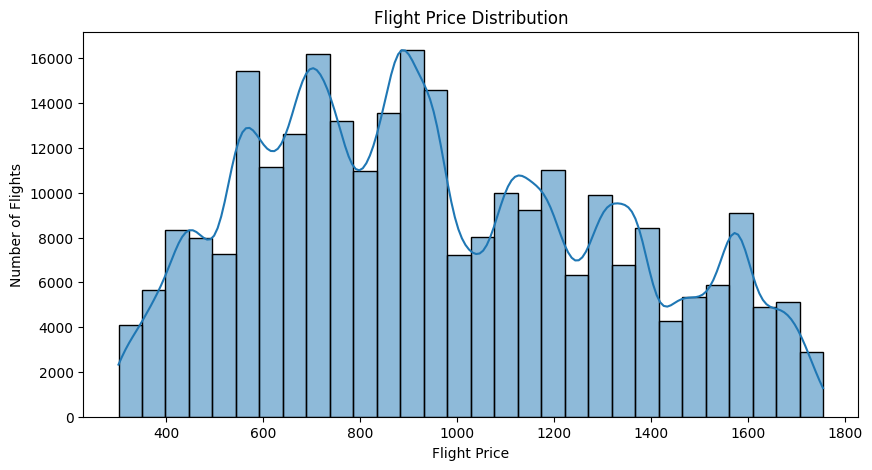

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    y,
    bins=30,
    kde=True
)

plt.title("Flight Price Distribution")
plt.xlabel("Flight Price")
plt.ylabel("Number of Flights")

plt.show()

In [ ]:
numeric_features = [
    "time",
    "distance",
    "year",
    "month",
    "day",
    "day_of_week",
    "is_weekend"
]

In [ ]:
categorical_features = [
    "from",
    "to",
    "flightType",
    "agency"
]

In [ ]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['time', 'distance', 'year', 'month', 'day', 'day_of_week', 'is_weekend']

Categorical features:
['from', 'to', 'flightType', 'agency']


In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [ ]:
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [ ]:
DummyRegressor

sklearn.dummy.DummyRegressor

In [ ]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyRegressor(
                strategy="mean"
            )
        )
    ]
)

In [ ]:
baseline_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['time', 'distance', 'year',
                                                   'month', 'day',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['from', 'to', 'flightType',
                                                   'agency'])])),
                ('model', DummyRegressor())])

In [ ]:
baseline_predictions = baseline_pipeline.predict(
    X_test
)
baseline_predictions

array([956.97081111, 956.97081111, 956.97081111, ..., 956.97081111,
       956.97081111, 956.97081111])

In [ ]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 303.8514998111685
Baseline RMSE: 362.4249713045772
Baseline R²: -3.1078245897431245e-05


In [ ]:
linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

In [ ]:
linear_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['time', 'distance', 'year',
                                                   'month', 'day',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['from', 'to', 'flightType',
                                                   'agency'])])),
                ('model', LinearRegression())])

In [ ]:
linear_predictions = linear_pipeline.predict(
    X_test
)

In [ ]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 81.29936969882868
RMSE: 102.96331225824511
R²  : 0.9192872247140091


In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            min_samples_split=10,
            min_samples_leaf=5,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [ ]:
rf_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['time', 'distance', 'year',
                                                   'month', 'day',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['from', 'to', 'flightType',
                                                   'agency'])])),
                ('model',
                 RandomForestRegressor(max_depth=12, max_features='sqrt',
                                       min_samples_leaf=5, min_samples_split=10,
                                       n_jobs=-1, random_state=42))])

In [ ]:
rf_predictions = rf_pipeline.predict(
    X_test
)
rf_predictions

array([ 538.23007816,  803.6525204 ,  959.23291494, ..., 1544.51368481,
        867.80917105,  878.27884475])

In [ ]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
MAE : 19.54189058641115
RMSE: 25.391455672387355
R²  : 0.9950914584766822


In [ ]:
gb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

In [ ]:
gb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['time', 'distance', 'year',
                                                   'month', 'day',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['from', 'to', 'flightType',
                                                   'agency'])])),
                ('model', GradientBoostingRegressor(random_state=42))])

In [ ]:
gb_predictions = gb_pipeline.predict(
    X_test
)

In [ ]:
gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R²  :", gb_r2)

Gradient Boosting
MAE : 32.12452078074164
RMSE: 40.160510869251965
R²  : 0.9877206401150885


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

results = results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(
    results.round(3)
)

,Model,MAE,RMSE,R2
0,Random Forest,19.542,25.391,0.995
1,Gradient Boosting,32.125,40.161,0.988
2,Linear Regression,81.299,102.963,0.919
3,Baseline,303.851,362.425,-0.000


In [ ]:
print("Duplicate rows in flight_ml_data:")
print(flight_data.duplicated().sum())

Duplicate rows in flight_ml_data:
0


In [ ]:
print("Duplicate rows in X:")
print(X.duplicated().sum())

Duplicate rows in X:
122404


In [ ]:
print("Dataset shape:", flight_data.shape)

print(
    "Exact duplicate rows:",
    flight_data.duplicated().sum()
)

print(
    "Duplicate feature rows:",
    X.duplicated().sum()
)

Dataset shape: (271888, 13)
Exact duplicate rows: 0
Duplicate feature rows: 122404


In [ ]:
flight_features = [
    "from", "to", "flightType", "time",
    "distance", "agency", "year", "month",
    "day", "day_of_week", "is_weekend"
]

feature_price_check = (
    flight_data
    .groupby(flight_features)["price"]
    .agg(record_count="count", unique_prices="nunique")
    .reset_index()
)

print("Duplicate feature combinations:", (feature_price_check["record_count"] > 1).sum())
print("Combinations with identical prices:", (feature_price_check["unique_prices"] == 1).sum())

Duplicate feature combinations: 60594
Combinations with identical prices: 149484


In [ ]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            xgb.XGBRegressor(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
xgb_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['time', 'distance', 'year',
                                                   'month', 'day',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['from', 'to', 'flightType',
                                                   'agency'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=Non...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [ ]:
xgb_predictions = xgb_pipeline.predict(
    X_test
)

In [ ]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)
print("R²  :", xgb_r2)

XGBoost
MAE : 6.225118301092016
RMSE: 8.204177478579108
R²  : 0.9994875548772539


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],

    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        gb_mae,
        xgb_mae
    ],

    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse
    ],

    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        gb_r2,
        xgb_r2
    ]
})

results = results.sort_values(
    "RMSE"
).reset_index(drop=True)

display(
    results.round(3)
)

,Model,MAE,RMSE,R2
0,XGBoost,6.225,8.204,0.999
1,Random Forest,19.542,25.391,0.995
2,Gradient Boosting,32.125,40.161,0.988
3,Linear Regression,81.299,102.963,0.919
4,Baseline,303.851,362.425,-0.000


## Hyperparameter Tuning — XGBoost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    "model__n_estimators": [200, 300, 500, 700],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 10]
}

In [ ]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['time',
                                                                                'distance',
                                                                                'year',
                                                                                'month',
                                                                                'day',
                                                                                'day_of_week',
                                                                                'is_weekend']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('onehot',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['from',
                                                                                'to',
                                                                                'flightType',
                                                                                'agency'])])),
                                             ('model',
                                              XGBReg...
                                                           num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    0.9, 1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [3, 4, 5, 6, 8],
                                        'model__min_child_weight': [1, 3, 5,
                                                                    10],
                                        'model__n_estimators': [200, 300, 500,
                                                                700],
                                        'model__subsample': [0.7, 0.8, 0.9,
                                                             1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)